In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

### Assignment 1 (4 scores):

- Use Numpy only to construct the Logistic Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset. *Note that three class in this dataset must be merge into two class as: graduate and non-graduate (dropout or enroll)*.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [2]:
df = pd.read_csv("C:/Users/nguye/DS102/Lab02/dataset.csv")

In [3]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nacionality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9   Mother's occupation                      

None

In [4]:
df.head(10)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Nacionality,Mother's qualification,Father's qualification,Mother's occupation,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,8,5,2,1,1,1,13,10,6,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,6,1,11,1,1,1,1,3,4,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,5,1,1,1,22,27,10,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,8,2,15,1,1,1,23,27,6,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,12,1,3,0,1,1,22,28,10,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
5,2,12,1,17,0,12,1,22,27,10,...,0,5,17,5,11.500000,5,16.2,0.3,-0.92,Graduate
6,1,1,1,12,1,1,1,13,28,8,...,0,8,8,8,14.345000,0,15.5,2.8,-4.06,Graduate
7,1,9,4,11,1,1,1,22,27,10,...,0,5,5,0,0.000000,0,15.5,2.8,-4.06,Dropout
8,1,1,3,10,1,1,15,1,1,10,...,0,6,7,6,14.142857,0,16.2,0.3,-0.92,Graduate
9,1,1,1,10,1,1,1,1,14,5,...,0,6,14,2,13.500000,0,8.9,1.4,3.51,Dropout


In [5]:
for col in df.columns:
  print(col, df[col].unique())

Marital status [1 2 4 3 5 6]
Application mode [ 8  6  1 12  9 17 15 16 14  4 13  7  3  2  5 18 10 11]
Application order [5 1 2 4 3 6 9 0]
Course [ 2 11  5 15  3 17 12 10 14 16  6  8 13  9  4  1  7]
Daytime/evening attendance [1 0]
Previous qualification [ 1 12 16 14  8  3 15  2  4  9 17 11  6  7 13  5 10]
Nacionality [ 1 15  3 14 12 18  5 11  8 17  4  9 13 16 10 21  2 20 19  6  7]
Mother's qualification [13  1 22 23  3  4 27  2 19 10 25  7  5 24  9 26 18 11 20 21  6  8 17 28
 12 14 16 15 29]
Father's qualification [10  3 27 28  1 14  5  4 24  2 29  9  7 26 18 30 12 15 25 31 16 11 20 33
 13 32  8  6 21 17 34 23 19 22]
Mother's occupation [ 6  4 10  8  5  2 16  1  7  3 12  9 20 28 13 29 23 32 30 18 24 19 11 21
 15 27 31 14 22 17 26 25]
Father's occupation [10  4  8 11  6  9  5  2  3 22  7  1 12 39 19 13 29 46 43 34 44 30 41 24
 23 45 35 26 28 36 16 37 31 42 20 15 40 25 21 17 32 38 27 18 14 33]
Displaced [1 0]
Educational special needs [0 1]
Debtor [0 1]
Tuition fees up to date [1 0]
Gend

In [6]:
def Target_encoder(Target):
  if Target == 'Graduate':
    return 1
  else:
    return 0
df['Target'] = df['Target'].apply(Target_encoder)

In [7]:
def preprocessing(df):
  BienNhiPhan = {"Daytime/evening attendance",
                "Displaced",
                "Educational special needs",
                "Debtor",
                "Tuition fees up to date",
                "Gender",
                "Scholarship holder",
                "International",
                 "Target"}
  for col in df.columns:
    if col not in BienNhiPhan:
      df[col] = (df[col] - df[col].mean())/df[col].std()
  return df
df = preprocessing(df)


In [8]:
for col in df.columns:
  print(col, df[col].unique())

Marital status [-0.29479543  1.35605896  4.65776772  3.00691334  6.3086221   7.95947648]
Application mode [ 0.21004482 -0.16738747 -1.11096819  0.9649094   0.39876097  1.90849012
  1.53105783  1.71977397  1.34234169 -0.54481975  1.15362554  0.02132868
 -0.7335359  -0.92225204 -0.35610361  2.09720626  0.58747711  0.77619325]
Application order [ 2.49061435 -0.55400513  0.20714974  1.72945948  0.96830461  3.25176922
  5.53523383 -1.31516   ]
Course [-1.82353777  0.25412433 -1.13098373  1.17752971 -1.59268642  1.6392324
  0.48497568  0.02327299  0.94667837  1.40838105 -0.90013239 -0.4384297
  0.71582702 -0.20757836 -1.36183508 -2.05438911 -0.66928105]
Daytime/evening attendance [1 0]
Previous qualification [-0.38636043  2.3888195   3.39797584  2.89339767  1.37966316  0.11821774
  3.14568676 -0.13407135  0.37050682  1.63195225  3.65026493  2.13653042
  0.87508499  1.12737408  2.64110859  0.62279591  1.88424133]
Nacionality [-0.14556962  7.86153533  0.99830251  7.28959926  6.14572713  9.5773

### Cách làm: 
- Đối với label, ta encode về 2 dạng chính mà đề yêu cầu 
- Với các feature khác, ta chia ra làm 2 nhóm là nhóm nhị phân và không nhị phân, với các biến không nhị phân ta sẽ chuẩn hóa đưa về kì vọng là 0 và phương sai là 1

In [9]:
import numpy as np
from tqdm import tqdm

class QuanLogisticRegression:
    def __init__(self, epoch: int, lr: float):
        self.epoch = epoch
        self.lr = lr
        self.losses = []
        self.metrics = []
        self.w = None
        self.b = None

    def sigmoid(self, x: np.ndarray) -> np.ndarray:
        return 1 / (1 + np.exp(-x))

    def loss_func(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-10  # Đảm bảo tránh log(0)
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return (y == y_hat).mean()

    def predict(self, X: np.ndarray) -> np.ndarray:
        y_hat = self.sigmoid(np.dot(X, self.w) + self.b)
        return (y_hat >= 0.5).astype(int)  # Sửa dấu phẩy thành chấm

    def GradientDescent(self, X: np.ndarray, y: np.ndarray) -> None:
        n_sample, n_feature = X.shape
        if self.w is None:
            self.w = np.zeros(n_feature)
            self.b = 0

        for epoch in tqdm(range(self.epoch), desc="Epochs"):
            # Tính giá trị dự đoán
            y_hat = self.sigmoid(np.dot(X, self.w) + self.b)

            # Tính gradient cho w và b
            dw = np.dot(X.T, (y_hat - y)) / n_sample
            db = np.sum(y_hat - y) / n_sample

            # Cập nhật trọng số và bias
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Tính loss và accuracy sau mỗi epoch
            loss = self.loss_func(y, y_hat)
            y_pred = (y_hat >= 0.5).astype(int)
            acc = self.accuracy(y, y_pred)

            self.losses.append(loss)
            self.metrics.append(acc)

            print(f"Epoch: {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.GradientDescent(X, y)

### Xây dựng logistic regression với nhãn nhị phân:
- ta sẽ thiết kế 2 đặc tính cơ bản của mô hình như hàm sigmoid, và accuracy để đo lường độ chính xác của mô hình 
- Sau đó là thiết kế hàm tính loss dựa theo công thức cross-entropy 
- Xây dựng Gradient Descent với công thức, sau đó tính loss và accuracy của mô hình sau mỗi epoch 
- Hàm fit để tìm kiếm tham số cho mô hình 

In [10]:
X1 = df.drop('Target', axis = 1)
y1 = df['Target']


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size=0.2, random_state=42)

In [12]:
model = QuanLogisticRegression(epoch=1000, lr=0.08)

In [13]:

model.fit(X_train, y_train)

Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch: 1, Loss: 0.6931, Accuracy: 0.5061
Epoch: 2, Loss: 0.6703, Accuracy: 0.7739
Epoch: 3, Loss: 0.6509, Accuracy: 0.7745
Epoch: 4, Loss: 0.6344, Accuracy: 0.7742
Epoch: 5, Loss: 0.6200, Accuracy: 0.7768
Epoch: 6, Loss: 0.6075, Accuracy: 0.7779
Epoch: 7, Loss: 0.5965, Accuracy: 0.7802
Epoch: 8, Loss: 0.5867, Accuracy: 0.7816
Epoch: 9, Loss: 0.5779, Accuracy: 0.7830
Epoch: 10, Loss: 0.5700, Accuracy: 0.7836
Epoch: 11, Loss: 0.5628, Accuracy: 0.7855
Epoch: 12, Loss: 0.5562, Accuracy: 0.7872
Epoch: 13, Loss: 0.5501, Accuracy: 0.7886
Epoch: 14, Loss: 0.5445, Accuracy: 0.7895
Epoch: 15, Loss: 0.5393, Accuracy: 0.7898
Epoch: 16, Loss: 0.5344, Accuracy: 0.7912
Epoch: 17, Loss: 0.5299, Accuracy: 0.7934
Epoch: 18, Loss: 0.5256, Accuracy: 0.7951
Epoch: 19, Loss: 0.5216, Accuracy: 0.7968
Epoch: 20, Loss: 0.5178, Accuracy: 0.8005
Epoch: 21, Loss: 0.5142, Accuracy: 0.8022
Epoch: 22, Loss: 0.5108, Accuracy: 0.8031
Epoch: 23, Loss: 0.5076, Accuracy: 0.8045
Epoch: 24, Loss: 0.5045, Accuracy: 0.8047
E

Epochs:  14%|█▎        | 136/1000 [00:00<00:01, 707.57it/s]

Epoch: 38, Loss: 0.4720, Accuracy: 0.8152
Epoch: 39, Loss: 0.4703, Accuracy: 0.8149
Epoch: 40, Loss: 0.4685, Accuracy: 0.8160
Epoch: 41, Loss: 0.4669, Accuracy: 0.8163
Epoch: 42, Loss: 0.4652, Accuracy: 0.8169
Epoch: 43, Loss: 0.4637, Accuracy: 0.8180
Epoch: 44, Loss: 0.4621, Accuracy: 0.8180
Epoch: 45, Loss: 0.4606, Accuracy: 0.8180
Epoch: 46, Loss: 0.4592, Accuracy: 0.8183
Epoch: 47, Loss: 0.4578, Accuracy: 0.8189
Epoch: 48, Loss: 0.4564, Accuracy: 0.8192
Epoch: 49, Loss: 0.4550, Accuracy: 0.8200
Epoch: 50, Loss: 0.4537, Accuracy: 0.8197
Epoch: 51, Loss: 0.4524, Accuracy: 0.8192
Epoch: 52, Loss: 0.4512, Accuracy: 0.8197
Epoch: 53, Loss: 0.4499, Accuracy: 0.8197
Epoch: 54, Loss: 0.4487, Accuracy: 0.8200
Epoch: 55, Loss: 0.4476, Accuracy: 0.8203
Epoch: 56, Loss: 0.4464, Accuracy: 0.8211
Epoch: 57, Loss: 0.4453, Accuracy: 0.8209
Epoch: 58, Loss: 0.4442, Accuracy: 0.8206
Epoch: 59, Loss: 0.4431, Accuracy: 0.8209
Epoch: 60, Loss: 0.4421, Accuracy: 0.8211
Epoch: 61, Loss: 0.4410, Accuracy:

Epochs:  31%|███       | 311/1000 [00:00<00:00, 818.84it/s]

...

Epoch: 757, Loss: 0.3454, Accuracy: 0.8437
Epoch: 758, Loss: 0.3454, Accuracy: 0.8437
Epoch: 759, Loss: 0.3454, Accuracy: 0.8437
Epoch: 760, Loss: 0.3453, Accuracy: 0.8437
Epoch: 761, Loss: 0.3453, Accuracy: 0.8437
Epoch: 762, Loss: 0.3453, Accuracy: 0.8437
Epoch: 763, Loss: 0.3453, Accuracy: 0.8440
Epoch: 764, Loss: 0.3453, Accuracy: 0.8440
Epoch: 765, Loss: 0.3452, Accuracy: 0.8443
Epoch: 766, Loss: 0.3452, Accuracy: 0.8443
Epoch: 767, Loss: 0.3452, Accuracy: 0.8443
Epoch: 768, Loss: 0.3452, Accuracy: 0.8443
Epoch: 769, Loss: 0.3451, Accuracy: 0.8443
Epoch: 770, Loss: 0.3451, Accuracy: 0.8443
Epoch: 771, Loss: 0.3451, Accuracy: 0.8443
Epoch: 772, Loss: 0.3451, Accuracy: 0.8443
Epoch: 773, Loss: 0.3450, Accuracy: 0.8443
Epoch: 774, Loss: 0.3450, Accuracy: 0.8443
Epoch: 775, Loss: 0.3450, Accuracy: 0.8443
Epoch: 776, Loss: 0.3450, Accuracy: 0.8443
Epoch: 777, Loss: 0.3450, Accuracy: 0.8443
Epoch: 778, Loss: 0.3449, Accuracy: 0.8443
Epoch: 779, Loss: 0.3449, Accuracy: 0.8443
Epoch: 780,

Epochs:  87%|████████▋ | 870/1000 [00:01<00:00, 513.64it/s]

Epoch: 817, Loss: 0.3441, Accuracy: 0.8449
Epoch: 818, Loss: 0.3441, Accuracy: 0.8449
Epoch: 819, Loss: 0.3440, Accuracy: 0.8449
Epoch: 820, Loss: 0.3440, Accuracy: 0.8449
Epoch: 821, Loss: 0.3440, Accuracy: 0.8449
Epoch: 822, Loss: 0.3440, Accuracy: 0.8449
Epoch: 823, Loss: 0.3439, Accuracy: 0.8449
Epoch: 824, Loss: 0.3439, Accuracy: 0.8446
Epoch: 825, Loss: 0.3439, Accuracy: 0.8446
Epoch: 826, Loss: 0.3439, Accuracy: 0.8443
Epoch: 827, Loss: 0.3439, Accuracy: 0.8443
Epoch: 828, Loss: 0.3438, Accuracy: 0.8443
Epoch: 829, Loss: 0.3438, Accuracy: 0.8443
Epoch: 830, Loss: 0.3438, Accuracy: 0.8443
Epoch: 831, Loss: 0.3438, Accuracy: 0.8443
Epoch: 832, Loss: 0.3438, Accuracy: 0.8443
Epoch: 833, Loss: 0.3437, Accuracy: 0.8443
Epoch: 834, Loss: 0.3437, Accuracy: 0.8443
Epoch: 835, Loss: 0.3437, Accuracy: 0.8443
Epoch: 836, Loss: 0.3437, Accuracy: 0.8443
Epoch: 837, Loss: 0.3437, Accuracy: 0.8443
Epoch: 838, Loss: 0.3436, Accuracy: 0.8443
Epoch: 839, Loss: 0.3436, Accuracy: 0.8443
Epoch: 840,

Epochs: 100%|██████████| 1000/1000 [00:01<00:00, 693.86it/s]

Epoch: 924, Loss: 0.3420, Accuracy: 0.8457
Epoch: 925, Loss: 0.3420, Accuracy: 0.8457
Epoch: 926, Loss: 0.3420, Accuracy: 0.8457
Epoch: 927, Loss: 0.3420, Accuracy: 0.8457
Epoch: 928, Loss: 0.3420, Accuracy: 0.8457
Epoch: 929, Loss: 0.3419, Accuracy: 0.8457
Epoch: 930, Loss: 0.3419, Accuracy: 0.8457
Epoch: 931, Loss: 0.3419, Accuracy: 0.8457
Epoch: 932, Loss: 0.3419, Accuracy: 0.8457
Epoch: 933, Loss: 0.3419, Accuracy: 0.8457
Epoch: 934, Loss: 0.3419, Accuracy: 0.8460
Epoch: 935, Loss: 0.3418, Accuracy: 0.8460
Epoch: 936, Loss: 0.3418, Accuracy: 0.8460
Epoch: 937, Loss: 0.3418, Accuracy: 0.8460
Epoch: 938, Loss: 0.3418, Accuracy: 0.8460
Epoch: 939, Loss: 0.3418, Accuracy: 0.8460
Epoch: 940, Loss: 0.3418, Accuracy: 0.8460
Epoch: 941, Loss: 0.3417, Accuracy: 0.8460
Epoch: 942, Loss: 0.3417, Accuracy: 0.8457
Epoch: 943, Loss: 0.3417, Accuracy: 0.8457
Epoch: 944, Loss: 0.3417, Accuracy: 0.8457
Epoch: 945, Loss: 0.3417, Accuracy: 0.8457
Epoch: 946, Loss: 0.3417, Accuracy: 0.8457
Epoch: 947,

In [14]:
y_pred = model.predict(X_test)
print (model.accuracy(y_test, y_pred))

0.8305084745762712


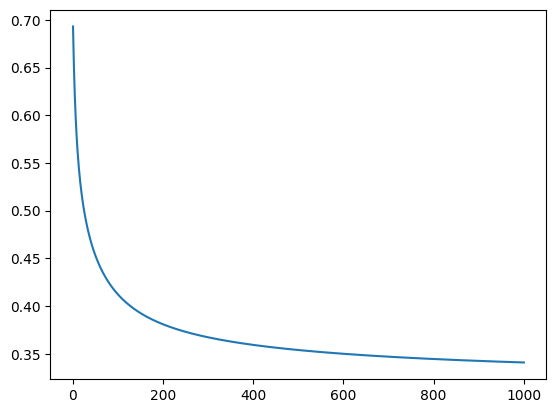

In [15]:
plt.plot(range(1, len(model.losses) + 1), model.losses)

### Nhận xét: 
- Có thể thấy loss của mô hình giảm theo các epoch, và dần hội tụ sau epoch > 1000, đạt độ chính xác trên tập test là 0.8305 gần với accuracy của tập train => có thể thấy mô hình ta đang khái quát hóa dữ liệu rất tốt 

### Assignment 2 (4 scores):

- Use Numpy only to construct the Sofmax Regression model.
- Train that Logistic Regression model dataset using the Gradient Descent approach on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Evaluate that Logistic Regression model on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Visualize the loss function of the training process.

In [16]:
class SoftmaxLogisticRegression:
    def __init__(self, epoch: int, lr: float, num_classes: int):
        self.epoch = epoch
        self.lr = lr
        self.num_classes = num_classes
        self.losses = []
        self.metrics = []
        self.w = None
        self.b = None

    def softmax(self, z: np.ndarray) -> np.ndarray:
        exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def loss_func(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        eps = 1e-10
        y_hat = np.clip(y_hat, eps, 1 - eps)
        return -np.mean(np.sum(y * np.log(y_hat), axis=1))

    def accuracy(self, y: np.ndarray, y_hat: np.ndarray) -> float:
        return np.mean(np.argmax(y_hat, axis=1) == np.argmax(y, axis=1))

    def predict(self, X: np.ndarray) -> np.ndarray:
        z = np.dot(X, self.w) + self.b
        y_hat = self.softmax(z)
        return np.argmax(y_hat, axis=1)

    def GradientDescent(self, X: np.ndarray, y: np.ndarray) -> None:
        n_sample, n_feature = X.shape
        if self.w is None:
            self.w = np.zeros((n_feature, self.num_classes))
            self.b = np.zeros(self.num_classes)

        for epoch in tqdm(range(self.epoch), desc="Epochs"):
            # Tính giá trị dự đoán với softmax
            z = np.dot(X, self.w) + self.b
            y_hat = self.softmax(z)

            # Tính gradient cho W và b
            dw = np.dot(X.T, (y_hat - y)) / n_sample
            db = np.sum(y_hat - y, axis=0) / n_sample

            # Cập nhật trọng số và bias
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # Tính loss và accuracy sau mỗi epoch
            loss = self.loss_func(y, y_hat)
            acc = self.accuracy(y, y_hat)

            self.losses.append(loss)
            self.metrics.append(acc)

            print(f"Epoch: {epoch+1}, Loss: {loss:.4f}, Accuracy: {acc:.4f}")

    def fit(self, X: np.ndarray, y: np.ndarray) -> None:
        self.GradientDescent(X, y)

### nhận xét
Khác với logistic regression sử dụng sigmoid cho bài toán nhị phân, softmax được sử dụng cho bài toán phân loại đa lớp. Đầu ra của mô hình là một vector xác suất, trong đó mỗi phần tử biểu diễn xác suất của một lớp và tổng các xác suất bằng 1. 
- Mô hình sẽ chọn lớp có xác suất cao nhất làm kết quả dự đoán. 
- Vậy nên ta chỉ cần chỉnh lại 1 số hàm trong Logistic gốc thì sẽ tạo ra được mô hình softmax này 

In [17]:
df = pd.read_csv(r"C:\Users\nguye\DS102\Lab02\dataset.csv")

In [18]:
def Target_encoder(Target):
  if Target == 'Graduate':
    return 2
  elif Target == "Dropout":
    return 0
  else:
    return 1
df['Target'] = df['Target'].apply(Target_encoder)

In [19]:
X2 = df.drop('Target', axis = 1)
y2 = df['Target']

In [20]:
X2.shape
y2.value_counts()

Target
2    2209
0    1421
1     794
Name: count, dtype: int64

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size = 0.2, random_state = 42)
y_train = np.eye(3)[y_train]
y_test = np.eye(3)[y_test]

In [22]:
model = SoftmaxLogisticRegression(epoch = 10000, lr = 0.005, num_classes = 3)
model.fit(X_train, y_train)


Epochs:   1%|▏         | 147/10000 [00:00<00:13, 743.35it/s]

Epoch: 1, Loss: 1.0986, Accuracy: 0.3122
Epoch: 2, Loss: 1.2847, Accuracy: 0.5061
Epoch: 3, Loss: 1.8880, Accuracy: 0.3122
Epoch: 4, Loss: 2.2591, Accuracy: 0.5061
Epoch: 5, Loss: 1.7068, Accuracy: 0.1817
Epoch: 6, Loss: 1.8086, Accuracy: 0.5363
Epoch: 7, Loss: 2.0827, Accuracy: 0.3122
Epoch: 8, Loss: 2.6039, Accuracy: 0.5061
Epoch: 9, Loss: 1.1989, Accuracy: 0.3040
Epoch: 10, Loss: 1.5113, Accuracy: 0.6084
Epoch: 11, Loss: 1.5401, Accuracy: 0.3238
Epoch: 12, Loss: 2.0170, Accuracy: 0.5061
Epoch: 13, Loss: 1.4098, Accuracy: 0.3035
Epoch: 14, Loss: 1.6057, Accuracy: 0.6304
Epoch: 15, Loss: 1.4121, Accuracy: 0.4049
Epoch: 16, Loss: 1.7105, Accuracy: 0.5129
Epoch: 17, Loss: 1.2684, Accuracy: 0.3354
Epoch: 18, Loss: 1.4547, Accuracy: 0.6296
Epoch: 19, Loss: 1.1822, Accuracy: 0.4691
Epoch: 20, Loss: 1.4042, Accuracy: 0.5544
Epoch: 21, Loss: 1.1396, Accuracy: 0.3555
Epoch: 22, Loss: 1.3379, Accuracy: 0.6363
Epoch: 23, Loss: 1.0649, Accuracy: 0.5369
Epoch: 24, Loss: 1.2233, Accuracy: 0.5993
E

Epochs:   2%|▏         | 222/10000 [00:00<00:13, 740.44it/s]

Epoch: 157, Loss: 0.6843, Accuracy: 0.7231
Epoch: 158, Loss: 0.6897, Accuracy: 0.7101
Epoch: 159, Loss: 0.6825, Accuracy: 0.7237
Epoch: 160, Loss: 0.6877, Accuracy: 0.7101
Epoch: 161, Loss: 0.6808, Accuracy: 0.7237
Epoch: 162, Loss: 0.6857, Accuracy: 0.7101
Epoch: 163, Loss: 0.6791, Accuracy: 0.7234
Epoch: 164, Loss: 0.6837, Accuracy: 0.7115
Epoch: 165, Loss: 0.6775, Accuracy: 0.7245
Epoch: 166, Loss: 0.6818, Accuracy: 0.7121
Epoch: 167, Loss: 0.6759, Accuracy: 0.7262
Epoch: 168, Loss: 0.6800, Accuracy: 0.7132
Epoch: 169, Loss: 0.6744, Accuracy: 0.7265
Epoch: 170, Loss: 0.6782, Accuracy: 0.7135
Epoch: 171, Loss: 0.6729, Accuracy: 0.7262
Epoch: 172, Loss: 0.6765, Accuracy: 0.7138
Epoch: 173, Loss: 0.6714, Accuracy: 0.7270
Epoch: 174, Loss: 0.6748, Accuracy: 0.7152
Epoch: 175, Loss: 0.6700, Accuracy: 0.7270
Epoch: 176, Loss: 0.6732, Accuracy: 0.7155
Epoch: 177, Loss: 0.6686, Accuracy: 0.7276
Epoch: 178, Loss: 0.6717, Accuracy: 0.7172
Epoch: 179, Loss: 0.6673, Accuracy: 0.7279
Epoch: 180,

Epochs:   3%|▎         | 297/10000 [00:00<00:22, 426.77it/s]

...

Epoch: 9811, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9812, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9813, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9814, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9815, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9816, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9817, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9818, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9819, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9820, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9821, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9822, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9823, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9824, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9825, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9826, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9827, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9828, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9829, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9830, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9831, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9832, Loss: 0.5519, Accuracy: 0.7754
Epoch: 9833, Loss: 0.5519, Accur

Epochs:  99%|█████████▉| 9893/10000 [00:24<00:00, 235.83it/s]

Epoch: 9872, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9873, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9874, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9875, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9876, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9877, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9878, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9879, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9880, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9881, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9882, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9883, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9884, Loss: 0.5518, Accuracy: 0.7754
Epoch: 9885, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9886, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9887, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9888, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9889, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9890, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9891, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9892, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9893, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9894, Loss: 0.5518, Accur

Epochs: 100%|██████████| 10000/10000 [00:24<00:00, 407.77it/s]

Epoch: 9926, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9927, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9928, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9929, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9930, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9931, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9932, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9933, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9934, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9935, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9936, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9937, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9938, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9939, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9940, Loss: 0.5518, Accuracy: 0.7756
Epoch: 9941, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9942, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9943, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9944, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9945, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9946, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9947, Loss: 0.5518, Accuracy: 0.7759
Epoch: 9948, Loss: 0.5518, Accur

In [23]:
y_pred = model.predict(X_test)
y_pred = np.eye(3)[y_pred]
print(model.accuracy(y_test, y_pred))

0.751412429378531


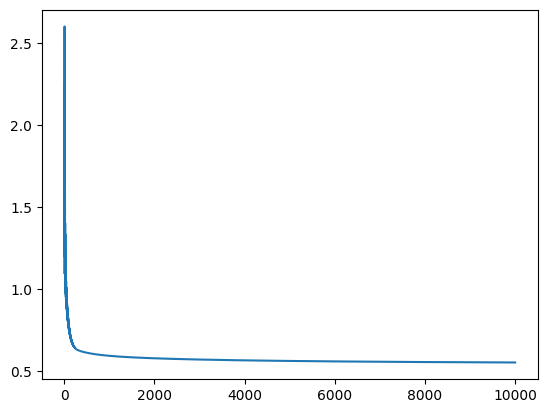

In [24]:
plt.plot(range(1, len(model.losses) + 1), model.losses)

### Nhận xét:
- Có thể thấy mô hình đang học rất tốt khi dần hội tụ vào những epoch > 1000, đồng thời độ chính xác tập test (0.751) gần với độ chính xác tập train (0,7762) cho thấy mô hình đang khái quát rất tốt

### Assignment 3 (2 scores):

- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Logistic Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.
- Use a Machine Learning library (Scikit Learn or Skorch) to implement and evaluate the Softmax Regression on the [Predict students’ dropout and academic success](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success) dataset.

#### Với softmax

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size = 0.2, random_state = 42)
model = LogisticRegression(max_iter= 1000, multi_class='multinomial', solver='lbfgs')
model.fit(X_train, y_train)

c:\Users\nguye\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\nguye\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [30]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.7559322033898305


#### Với Logistic

In [31]:
X_train, X_test, y_train, y_test = train_test_split(X1, y1, test_size = 0.2, random_state = 42)
model = LogisticRegression(max_iter= 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [32]:
y_pred = model.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.8418079096045198


### Nhận xét: 
- Với mô hình logistic, sklearn cho ra kết quả trên tập test là 0,842 trong khi đó mô hình logistic của ta cho ra 0,831 chênh lệch 0,011 
- Với mô hình softmax, sklearn cho ra kết quả 0,756 trong khi mô hình softmax ta cho ra 0,751 chênh lệch 0,005 

=> Giải thích cho sự chênh lệch này, không phải do mô hình ta kém mà do sự khác biệt về siêu tham số, có thể là do ta chưa đưa ra được tốc độ học tối ưu, ngoài ra sklearn còn sử dụng optimizer mạnh hơn gradient descent nhiều, hội tụ nhanh và chính xác hơn. Tóm lại sự chênh lệch nhỏ này là có nguyên nhân, còn thuật toán của mô hình đã hội tụ tốt, khái quát hóa được ảnh hưởng đặc trưng đến nhãn.